<a href="https://colab.research.google.com/github/Clover130/Seismic-Babes-Group-Project-1/blob/main/EMSC2010_Group_Project_1_Seismic_Babes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Seismic Babes Group Project 1

## 1. Project Overview
Group name: Seismic Babes

Project week: Week 5 to 6

Project title: Crustal Thickness of Australia and South America

Datasets used (name and source): GPlatesPortal, Crustal and Lithospheric Thickness { https://portal.gplates.org/cesium/?view=crustal_litho_thickness }

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Clover | Owen | Yes/Partial/No| Add note|
| Data steward | Freddie | Clover | Yes/Partial/No| Add note|
| Analysis / modelling | Ed | Freddie | Yes/Partial/No| Add note|
| Visualisation / interpretation | Ellie | Justin | Yes/Partial/No| Add note|
| Narrative | Justin | Ellie | Yes/Partial/No| Add note|
| Quality Control / Reproducibility  | Owen | Ed | Yes/Partial/No/NA| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

##4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

#Question

## Project Question

Comparing the crustal densities of the Australian and South American continents via the estimation technique of bootstrapping

#Method

## STEP 1: Random point generation

The first step in acquiring data was to establish a repeatable methodology to create random data points for the two areas of interest. For this example, the team decided to use Australia and South America.

To achieve random or pseudo-random points, since it is still computer-generated, a few requirements are applied. The team decided to utilise Python to actively select points based on the two contents.

Thus, we needed to create a shp file with the bounds, i.e., latitude and longitude. To produce a .shp file that could be imported into Python, we downloaded a global coastline geopackage from the open-source website Natural Earth (https://www.naturalearthdata.com/downloads/). A 110-meter-resolution geopackage was acquired and processed in QGIS 3.40.

From here, the continent of interest was isolated and exported as a shapefile for import into Python. Using this newly created shapefile of Australia and South America, we adapted pre-existing code sourced from stackoverflow.com (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile).

By adapting this code, we successfully generated random points within the area of interest and saved them, along with their respective latitudes and longitudes, to a CSV file for further processing. This process was completed for both the Australian and the South American shapefiles. More instructions on the individual purpose and process of the code are explained within the cell.

Imported files are:
- Final_aus_bound.shp
- Final_aus-bound.shx
- south_amerrica.shp
- south_amerrica.shx


Justin

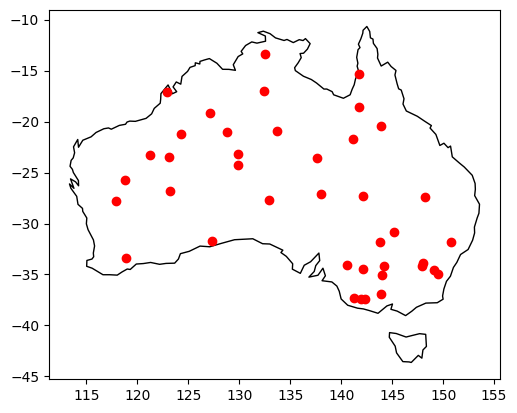

In [66]:
## Code sourced and adpated from (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile)
import random
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Initial shapefile created in QGIS is to be loaded and assigned
AUS_shapfile = "Final_aus_bound.shp"
gdf = gpd.read_file(AUS_shapfile)

### altered original code-
# e.g (aoi = gdf[gdf['ZCTA5CE10'] == zcta_to_use]) was not used as this was
# specific to find a specific zipcode
# within the shapfile in America; therefore, it was not needed for this
# Australian shapefile. (AI helped me identify this as an error.

# combine all polygons into one, this is grabbing all the individual shapefiles
# and collating them into one big shapefile or polygon.

aoi_geom = gdf.union_all()

# This assigns how many random points are to be generated within the shapefile bounds.

pointcount = 40

# The purpose of this code is to assign a min and max for both the x and y
# coordinates. What are the furthest northern and southern longitudes, and what
# are the furthest eastern and western latitudes?Thus, we end up with a
# rectangle around an Australian ready for the next step.

xmin, ymin, xmax, ymax = aoi_geom.bounds

# Now, with the newly created rectangle/bounding box around Australia, we
# started assigning pseudo-random points!using the analogy of throwing darts,
# the computer will continue to throw darts within the bounding box until 40 darts
#land within the shapfile ie Australia

points = []
while len(points) < pointcount:
    x = random.uniform(xmin, xmax)
    y = random.uniform(ymin, ymax)
    p = Point(x, y)

    if p.within(aoi_geom):
        points.append(p)

## this just gets all the random points we just generated and puts them into a
# series to allow for easier handling

gs = gpd.GeoSeries(points)

# to validate the random points, we can just plot to ensure all points are
# actually within the defined shapefile, and the latitude and longitude correctly
# match what we expect for Australia.

fig, ax = plt.subplots()
gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gs.plot(ax=ax, color='red')

plt.show()


# finally, to hand over to the data import team member the newly generated
# points and the corresponding latitude and longitude needs to be a CSV file.


gs.to_csv("/content/AUS_random_points.csv", index=False)


## rinse and repeat for the South America shapefile, and we have our two datasets!!!
##-JUSTIN'S code


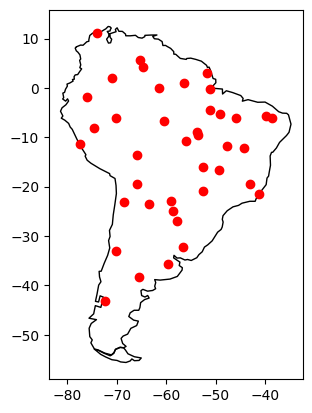

In [67]:
## Code sourced and adpated from (https://stackoverflow.com/questions/60534219/pyshp-generate-random-points-in-shapefile)
import random
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# Initial shapefile created in QGIS is to be loaded and assigned
SA_shapfile = "south_amerrica.shp"
gdf_SA = gpd.read_file(SA_shapfile)

### altered original code-
# e.g (aoi = gdf[gdf['ZCTA5CE10'] == zcta_to_use]) was not used as this was
# specific to find a specific zipcode within the shapfile in America; therefore,
# it was not needed for this South American shapefile. (AI helped me identify this
# as an error.

# combine all polygons into one, this is grabbing all the individual shapefiles
# and collating them into one big polygon.

aoi_geom_SA = gdf_SA.union_all()

# This assigns how many random points are to be generated within the shapefile bounds.

SA_pointcount = 40

# The purpose of this code is to assign a min and max for both the x and y
# coordinates. What are the furthest northern and southern longitudes, and what
# are the furthest eastern and western latitudes?
#Thus, we end up with a rectangle around an South America ready for the next step.

xmin_SA, ymin_SA, xmax_SA, ymax_SA = aoi_geom_SA.bounds

# Now, with the newly created rectangle/bounding box around South America, we
# started assigning pseudo-random points! using the analogy of throwing darts,
# the computer will continue to throw darts within the bounding box until 40 darts
#land within the shapfile ie South America

SA_points = []
while len(SA_points) < SA_pointcount:
    x_SA = random.uniform(xmin_SA, xmax_SA)
    y_SA = random.uniform(ymin_SA, ymax_SA)
    p_SA = Point(x_SA, y_SA)

    if p_SA.within(aoi_geom_SA):
        SA_points.append(p_SA)

# this just gets all the random points we just generated and puts them into a
# series to allow for easier handling

gs_SA = gpd.GeoSeries(SA_points)

# to validate the random points, we can just plot to ensure all points are
# actually within the defined shapefile, and the latitude and longitude
# correctly match what we expect for South America.

fig_SA, ax_SA = plt.subplots()
gdf_SA.plot(ax=ax_SA, facecolor='none', edgecolor='black')
gs_SA.plot(ax=ax_SA, color='red')

plt.show()


# finally, to hand over to the data import team member the newly generated
# points and the corresponding latitude and longitude needs to be a CSV file
# needs to be

gs_SA.to_csv("/content/SA_random_points.csv", index=False)

##-JUSTIN'S code




## STEP 2: Find continental crust thickness
## Data Import

With the newly created .csv files, containing the randomly generated coordinates located on the South American Continent and the other containing the Australian points, we procceded to take each coordinate and used the program Gplates bu Cesium (https://portal.gplates.org/cesium/?view=crustal_litho_thickness), to find the continental crust thickness at these specific coordinates. We used 40 points for each continent, so I repeated this process 40 times.  - Freddie

In [68]:
import pandas as pd

file_name = "Seismic Babes_Group Project 1_DataSet.xlsx"

df = pd.read_excel(file_name, header=None)

# Find completely blank rows
blank_rows = df[df.isnull().all(axis=1)].index

if len(blank_rows) == 0:
    raise ValueError("No blank rows found — cannot split tables")

# Split tables safely
table1 = df.iloc[:blank_rows[0]].reset_index(drop=True)
table2 = df.iloc[blank_rows[0] + 1:].reset_index(drop=True)

# Only set headers if tables are not empty
if not table1.empty:
    table1.columns = table1.iloc[0]
    table1 = table1[1:].reset_index(drop=True)
else:
    print("Warning: Table 1 is empty")

if not table2.empty:
    table2.columns = table2.iloc[0]
    table2 = table2[1:].reset_index(drop=True)
else:
    print("Warning: Table 2 is empty")

print("Table 1:")
print(table1)

print("\nTable 2:")
print(table2)

Table 1:
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Index: []

Table 2:
0   NaN Point #    Longitude      Latitude   \
0   NaN       1    -74.496015     -49.55041   
1   NaN       2    -55.125278     -27.82794   
2   NaN       3    -57.220806     -4.890713   
3   NaN       4    -46.871095    -13.320275   
4   NaN       5    -51.014127     -3.364726   
5   NaN       6    -66.392963      -3.72581   
6   NaN       7     -66.43568      8.502381   
7   NaN       8    -67.152112    -26.383269   
8   NaN       9     -71.19033    -10.417772   
9   NaN      10    -61.179751     -7.622409   
10  NaN      11    -64.991079    -35.405326   
11  NaN      12    -56.734374    -30.078724   
12  NaN      13    -36.956091     -6.621703   
13  NaN      14    -77.481836      0.016169   
14  NaN      15    -52.853689    -29.597547   
15  NaN      16    -35.551225     -5.522559   
16  NaN      17    -38.340573     -7.149303   
17  NaN      18    -67.803363    -16.009012   
18  NaN      19    -61

## STEP 3: Data Analysis

Applying bootstrapping techniques and finding confidence intervals

In [69]:
import numpy as np
X = np.array([41650,35805,41730,39536,36919,36826,37092,38840,40287,31435,44002,33410,39714,29944,35409,36203,42251,34643,30536,36956,32064,39604,34553,33392,35733,30523,37063,37283,32012,40541,37957,31746,37813,35544,36306,34501,31625,40057,33640,32003])

# X represents the array of crustal thickness for Australia

In [70]:
A = np.random.choice(X, size=(len(X),1000), replace=True)
print(np.shape(A))

## A represents a random selection from the data (with replacement)

(40, 1000)


In [71]:
barA = np.mean(A, axis=0)
print(np.shape(barA))

## barA represents the mean of columns of the bootstrapped crustal thicknesses data

(1000,)


In [72]:
CI_A = np.percentile(barA,[2.5,97.5])
print(CI_A)

## Computing confidence interval for Australia crustal thickness

[35019.5275   37329.606875]


In [73]:
Y = np.array([34322,35293,35039,39410,35067,35280,35828,55091,32356,36503,35437,36176,29607,39611,38196,20095,29776,60654,39834,32626,40245,35027,61185,39174,37772,37345,37636,35915,36660,40062,41767,44928,33984,36122,36792,36381,34633,36011,34524,39377])

## Y represents the crustal thickness of South

In [74]:
S = np.random.choice(Y, size=(len(Y),1000), replace=True)
print(np.shape(S))

## S represents a random selection from the data (with replacement)

(40, 1000)


In [75]:
barS = np.mean(S, axis=0)
print(np.shape(barS))

## barS represents the mean of columns of the bootstrapped crustal thicknesses data

(1000,)


In [76]:
CI_S = np.percentile(barS,[2.5,97.5])
print(CI_S)

## Computing confidence interval for South American crustal thickness

[35763.66875  40138.535625]


#Results

## Data Visualisation



Histograms

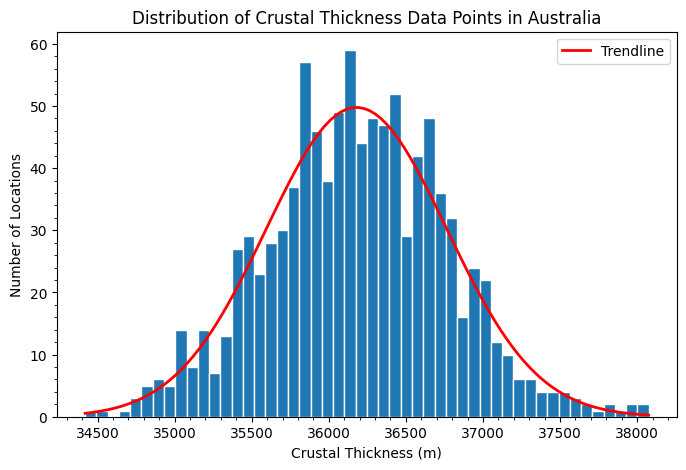

In [86]:
import matplotlib.pyplot as plt

dataA = barA #data to be used for this histogram, from Australian crustal thickness data

fig, ax = plt.subplots(figsize=(8,5))

n, bins, patches = ax.hist(
    dataA,
    bins=50,
    edgecolor='white'
)


#Formating histogram
ax.minorticks_on()
ax.set_xlabel('Crustal Thickness (m)') #text for the x-axis label
ax.set_ylabel('Number of Locations') #text for the y-axis label
plt.title("Distribution of Crustal Thickness Data Points in Australia")

#adding a trendline
mu = np.mean(dataA)
std = np.std(dataA)
x = np.linspace(dataA.min(), dataA.max(), 100)
p = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))  # normal distribution formula
p_scaled = p * len(dataA) * (bins[1] - bins[0])  # scale to match histogram y-axis

ax.plot(x, p_scaled, color='red', linewidth=2, label='Trendline')
ax.legend()

##-ELLIE'S code

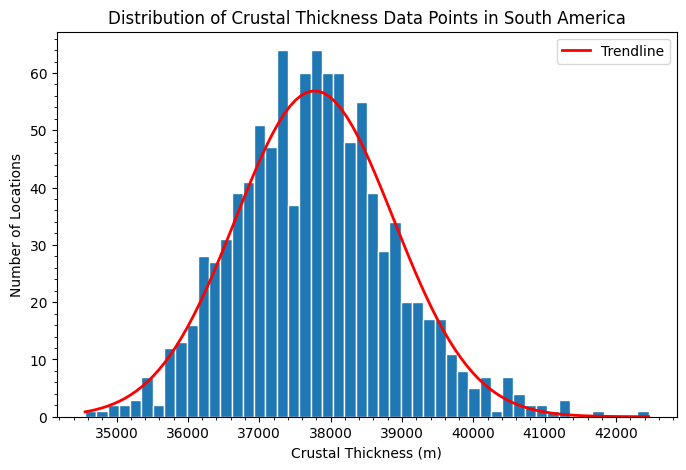

In [87]:
dataS = barS #data to be used for this histogram

fig, ax = plt.subplots(figsize=(8,5))

n, bins, patches = ax.hist(
    dataS,
    bins=50,
    edgecolor='white'
)

##-ED'S code

#formating histogram
ax.minorticks_on()
ax.set_xlabel('Crustal Thickness (m)') #text for the x-axis label
ax.set_ylabel('Number of Locations') #text for the y-axis label
plt.title("Distribution of Crustal Thickness Data Points in South America")

#adding a trendline
mu = np.mean(dataS)
std = np.std(dataS)
x = np.linspace(dataS.min(), dataS.max(), 100)
p = np.exp(-0.5 * ((x - mu) / std) ** 2) / (std * np.sqrt(2 * np.pi))  # normal distribution formula
p_scaled = p * len(dataS) * (bins[1] - bins[0])  # scale to match histogram y-axis

ax.plot(x, p_scaled, color='red', linewidth=2, label='Trendline')
ax.legend()

##-ELLIE'S code

Map Plotting of random points and their crustal thicknesses

In [79]:
#installing correct cartopy software for mapping
!apt-get install -qq libgdal-dev libgeos-dev libproj-dev
!pip install cartopy

##-ELLIE'S code

In [80]:
import pandas as pd #used to read and clean data
import cartopy.crs as ccrs #import map coordinate reference systems
import cartopy.feature as cfeature #imports Cartopy's map features

spreadsheet_name = 'Seismic Babes_Group Project 1_DataSet.xlsx'
worksheet_AU = 'AU' # The sheet name containing Australian Crustal Thickness data
worksheet_SA = 'SA' # The sheet name containing South American Crustal Thickness data

df_AU = pd.read_excel(spreadsheet_name, sheet_name=worksheet_AU) #read the Australian  data into a dataframe
df_SA = pd.read_excel(spreadsheet_name, sheet_name=worksheet_SA) #read the South American data into a dataframe

##-ELLIE'S code

In [81]:
df_AU.head() #show the dataframe table for AU

##-ELLIE'S code

,Longitude,Latitude,Crustal Thickness (m)
0,136.319401,-17.498567,41650
1,148.713268,-37.032490,35805
2,130.425892,-20.041320,41730
3,150.284505,-35.797133,39536
4,135.198613,-32.668681,36919


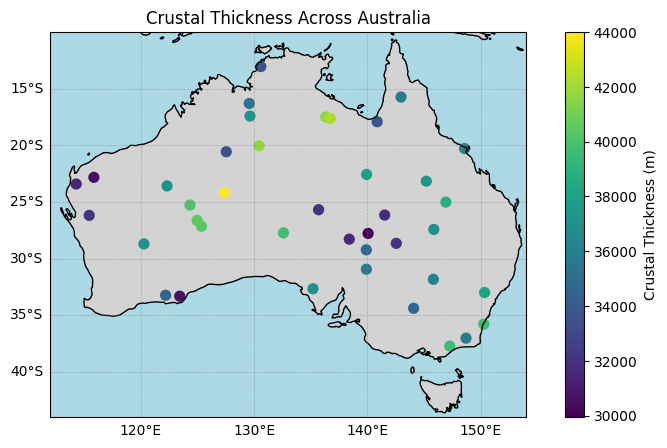

In [82]:
# MAP SETUP - AUSTRALIA

# Define the map projection to use Plate Carree
my_projection=ccrs.PlateCarree()

# Create a Matplotlib figure with a width of 10 inches and height of 5 inches
fig = plt.figure(figsize=(10, 5))

# Create a map axis using the chosen Cartopy projection
ax = plt.axes(projection=my_projection)

# Set the map extent to cover only Australia
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

# Draw coastlines on the map for geographic reference
ax.coastlines()

# Add land areas to the map and color them light gray
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Add ocean areas to the map and color them light blue
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Plot locations as a scatter plot
sc_AU = ax.scatter(
    df_AU['Longitude'], # Longitudes of Points (x-coordinates)
    df_AU['Latitude'], # Latitudes of Points (y-coordinates)
    c=df_AU['Crustal Thickness (m)'], # Color the markers by Crustal Thickness
    s=50, # Scale marker size
    cmap="viridis", # Use the 'viridis' colormap for thickness values
    transform=ccrs.PlateCarree()  # Specify the input coordinates are in Plate Carrée (lon/lat) projection
)

# shows how marker color corresponds to crustal thickness
plt.colorbar(sc_AU, label="Crustal Thickness (m)")

# Add a title to the figure
plt.title("Crustal Thickness Across Australia")

# Add latitude and longitude gridlines to the map
gl = ax.gridlines(
    draw_labels=True,     # Show coordinate labels on the map edges
    linewidth=0.5,        # Set gridline thickness
    color="gray",         # Set gridline color
    alpha=0.5,            # Make gridlines semi-transparent
    linestyle="--"        # Use dashed gridlines
)

gl.top_labels = False # Disable labels at the top of the map
gl.right_labels = False # Disable labels on the right side of the map

##-ELLIE'S code

In [83]:
df_SA.head() #show the dataframe table for SA

##-ELLIE'S code

,Longitude,Latitude,Crustal Thickness (m)
0,-74.496015,-49.550410,34322
1,-55.125278,-27.827940,35293
2,-57.220806,-4.890713,35039
3,-46.871095,-13.320275,39410
4,-51.014127,-3.364726,35067


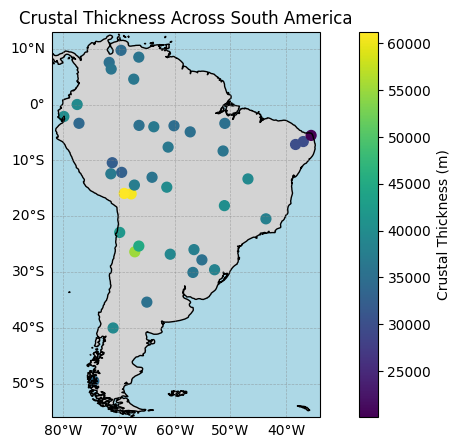

In [84]:
# MAP SETUP & ADD FEATURES - SOUTH AMERICA
#rinse and repeat steps from AU map to create SA map

my_projection=ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=my_projection)

ax.set_extent([-82, -34, -56, 13], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

sc_SA = ax.scatter(
    df_SA['Longitude'],
    df_SA['Latitude'],
    c=df_SA['Crustal Thickness (m)'],
    s=50,
    cmap="viridis",
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc_SA, label="Crustal Thickness (m)")
plt.title("Crustal Thickness Across South America")

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

##-ELLIE'S code

## Interpretation/Discussion

{discuss/compare results}

The following analysis examines crustal thickness distributions across Australia and South America using histogram and spatial map data.

**Australia**

The histogram for the Crustal Thickness in Australia, supported by the confidence interval, shows that majority of the Australian crust is approximately 35,000 m to 37,000 m thick, indicating a relatively narrow and uniform distribution. This uniformity is reflected spatially in the map, where most data points are in the teal/green range across Autralia's interior.

The map of Australian crustal thickness reveals that the west coast has mostly purple/dark blue dots, indicating thinner crust (30,000-32,000 m).
Moving eastward, the dots transition to green and yellow, suggesting thicker crust in central and eastern Australia.
The yellow dot in central Australia represents the thickest data point at approximately 44,000 m.

Overall, crustal thickness generally increases from west to east across Australia, with the thickest crust concentrated in the central to eastern interior. The thin crustal values in the west, despite the presence of ancient cratons, can be explained by the fact that they are associated with thick lithospheric keels extending into the mantle; however, this study only measures crustal thickness. The thinner crust in western Australia therefore reflects billions of years of erosion and tectonic stability, while the thicker crust in the east could be associated with more recent orogenic events.

**South America**

The histogram for crustal thickness in South America reveals that the continental crust is generally thicker than Australia's, ranging approximately from 36,000 m to 40,000 m based on confidence interval. This greater thickness is consistent with South America's more geologically active tectonic setting.

The map supports this, showing purple dots along the eastern Coast of Brazil, suggesting very thin crust (24,000 m). Most of central South America is fairly uniform and sits in the teal/blue range (35,000-40,000 m). The two yellow dots in western and central South America mark the thickest areas (48,000-50,000 m), likely corresponding to the Andes Mountain Range.

Overall there is a clear trend of crustal thickness decreasing from west to east across South America. This is geologically consistent, as the South American plate is overriding the NAZCA plate along the western edge of the continent, forming the Peru-Chile subduction zone and resulting in significant crustal thickening and the formation of the Andes.

**Comparison**

South America has a significantly larger confidence interval in crustal thickness compared to Australia, reflecting their vastly different tectonic settings. Australia is one of the oldest and most stable continental masses on Earth, resulting in a narrow range of crustal thickness. In contrast, South America is very geologically active due to the Peru-Chile subduction zone, producing a much wider range from highly thickened crust beneath the Andes in the west to thin coastal crust in the east.

However, as data points are sparse and unevenly distributed, these trends are indicative rather than definitive. To improve accuracy, additional data points should be collected to cover more area of Australia and South America.

#Individual Reflections

###Freddie (Data Steward)

###Ed (Analysis Modelling)

###Ellie (Visualisation/Interpretation)

Working with Ed on the histograms was straightforward, as the process was similar to what we did in week 5. I then further added titles, a trendline, and extra formatting using the skills learned in week 3, which was also relatively simple. However, I found mapping the data points to be harder and more time-consuming than expected. I originally chose the LambertConformal projection, which distorted the map and clipped the continent, requiring me to switch to PlateCaree projection and adjust the map boundaries, teaching me how projection centres affect the visible map area.
In the interpretation, I was initially confused as to why the crust was generally thinner over areas with cratons, as I expected their age and stability to correspond with greater crust thickness. After some reseach I learned that cratons are thicker when considering the full lithosphere, whereas this study only measures crustal thickness, leading me to rewrite that secton of my interpretation to be more geologically accurate.

###Clover (Github and Integration)

###Justin (Narrative)

###Owen (Quality Control/Reproducibility)